In [12]:
!python --version

Python 3.14.3


The system cannot find the path specified.


In [1]:
import numpy as np
import skimage
import scipy
import cv2 # certain modules used here and in the library aren't part of the vanilla OpenCV but opencv-contrib-python!!!
# opencv-contrib-python is a separate library and needs to be installed separately!
from PIL import Image
import matplotlib.pyplot as plt

import rootskel

In [3]:
roots = Image.open(r"./20260312_103230.jpg")
roots.mode # RGB is good

'RGB'

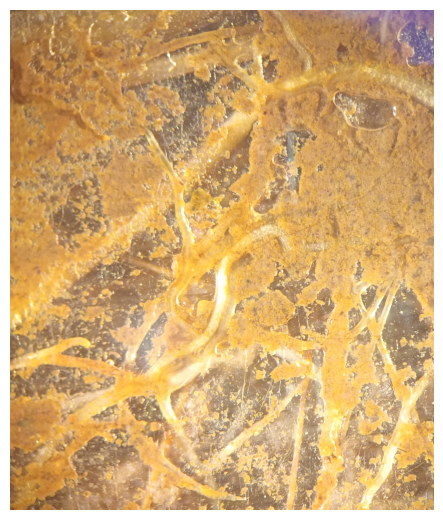

In [4]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 6.5)
axes.imshow(roots)
axes.set_axis_off()
plt.show()

In [5]:
roots = np.array(roots)
roots = cv2.cvtColor(src=roots, code=cv2.COLOR_RGB2GRAY) # greyscale transformation
cv2.bitwise_not(src=roots, dst=roots)
cv2.threshold(src=roots, thresh=0, maxval=255, type=cv2.THRESH_BINARY+cv2.THRESH_OTSU, dst=roots) # transform the greyscale image to binary

(82.0,
 array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],
       shape=(3966, 3356), dtype=uint8))

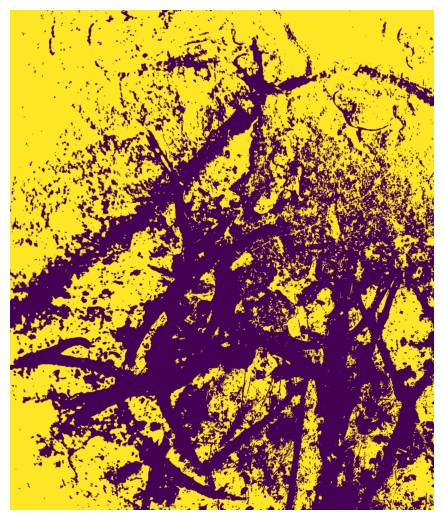

In [6]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 6.5)
axes.imshow(roots)
axes.set_axis_off()
plt.show()

In [7]:
cv2.ximgproc.thinning(src=roots, dst=roots)

array([[255, 255, 255, ..., 255, 255, 255],
       [255,   0,   0, ...,   0,   0, 255],
       [255,   0,   0, ...,   0,   0, 255],
       ...,
       [255,   0,   0, ...,   0,   0, 255],
       [255,   0,   0, ...,   0,   0, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(3966, 3356), dtype=uint8)

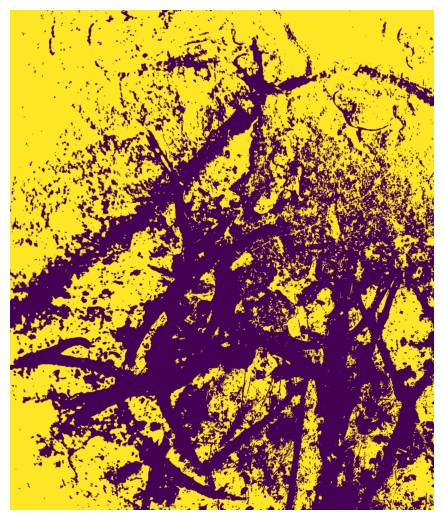

In [8]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 6.5)
axes.imshow(roots)
axes.set_axis_off()
plt.show()

In [9]:
nlabels, labels, stats, centroids = cv2.connectedComponentsWithStats(roots, 4, cv2.CV_32S)

In [10]:
labels # labels is a matrix the size of the input image where each element has a value equal to its label.

array([[   1,    1,    1, ...,    1,    1,    1],
       [   1,    1,    1, ...,    1,    1,    1],
       [   1,    1,    1, ...,    1,    1,    1],
       ...,
       [3115, 3115, 3115, ..., 3851, 3851, 3851],
       [3115, 3115, 3115, ..., 3851, 3851, 3851],
       [3115, 3115, 3115, ..., 3851, 3851, 3851]],
      shape=(3966, 3356), dtype=int32)

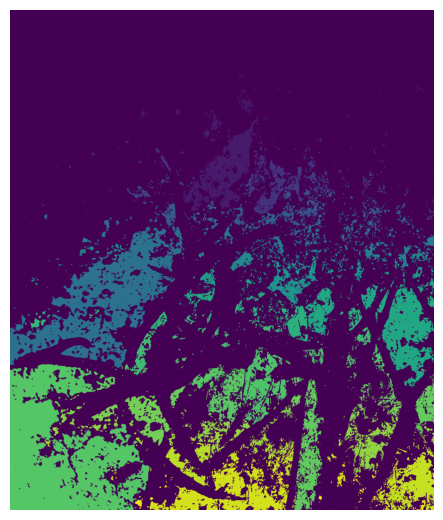

In [11]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 6.5)
axes.imshow(labels)
axes.set_axis_off()
plt.show()

In [80]:
nlabels # number of labels

4222

In [81]:
stats # stats is a matrix of the stats that the function calculates. it has a length equal to the number of labels and a width equal to the number of stats
# it can be used with the OpenCV documentation for it

array([[      0,       0,    3356,    3966, 6217364],
       [      0,       0,    3356,    2313, 4026276],
       [   1241,       0,       3,       2,       5],
       ...,
       [   2883,    3965,       2,       1,       2],
       [   2915,    3965,       1,       1,       1],
       [   3159,    3964,       2,       2,       3]],
      shape=(4222, 5), dtype=int32)

In [82]:
# stats computed by the function, for each label
cv2.CC_STAT_LEFT, cv2.CC_STAT_TOP, cv2.CC_STAT_WIDTH, cv2.CC_STAT_HEIGHT, cv2.CC_STAT_AREA

(0, 1, 2, 3, 4)